# 03 — Modeling

XGBoost + Logistic Regression na 12 kombinacjach (4 okna × 3 feature sets).

- **CV:** 10-fold stratified
- **Test:** held-out 20% split (per SUBJECT_ID) dla VS_RB_BG
- **Porównanie:** DeLong's test (XGB vs LR, pooled CV predictions)
- **SHAP:** T=1h, VS_RB_BG

> Uruchamiaj z katalogu `THS_Prediction/` lub upewnij się, że `config.py` jest na `sys.path`.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from scipy import stats
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              accuracy_score, precision_score, recall_score,
                              fbeta_score, confusion_matrix, roc_curve)
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

print("Environment ready.")
print(f"  XGBoost: {xgb.__version__}")


Environment ready.
  XGBoost: 2.0.3


## Parametry uruchomienia

In [2]:
# ── Parametry ────────────────────────────────────────────────────────────────
# FAST_MODE = True  → używa opublikowanych hiperparametrów (config.PUB_XGB_PARAMS)
#                     
# FAST_MODE = False → pełny GridSearchCV
#                     
# ── Parametry ────────────────────────────────────────────────────────────────
FAST_MODE = False

N_FOLDS     = 10
N_BOOTSTRAP = 1000
RANDOM_SEED = config.RANDOM_SEED
TIME_WINDOWS = config.TIME_WINDOWS     # [0.5, 1, 2, 3]

META_COLS = ['HADM_ID','SUBJECT_ID','TIME_WINDOW','REFERENCE_TIME',
             'ONSET_TIME','LABEL','HOURS_TO_SHOCK']

# ZMIANA: _ECG_CONT_NAMES usunięte z tej komórki i przeniesione piętro niżej!
ECG_COLS = ['ECG_RMSSD', 'ECG_SDNN', 'ECG_pNN50', 'ECG_MISSING']

print(f"FAST_MODE:   {FAST_MODE}")
print(f"N_FOLDS:     {N_FOLDS}")
print(f"N_BOOTSTRAP: {N_BOOTSTRAP}")
print(f"RANDOM_SEED: {RANDOM_SEED}")

FAST_MODE:   False
N_FOLDS:     10
N_BOOTSTRAP: 1000
RANDOM_SEED: 42


## Wczytanie danych

In [3]:
print("Loading imputed datasets...")
datasets = {}
for T in TIME_WINDOWS:
    datasets[T] = {}
    for ds in ['VS','VS_RB','VS_RB_BG']:
        fpath = config.IMPUTED_DIR / f'features_T{T}h_{ds}_imputed.csv'
        df = pd.read_csv(fpath)
        datasets[T][ds] = df

print("Loading train/test splits (VS_RB_BG, per SUBJECT_ID)...")
splits = {}
for T in TIME_WINDOWS:
    train = pd.read_csv(config.SPLIT_DIR / f'train_T{T}h_VS_RB_BG.csv')
    test  = pd.read_csv(config.SPLIT_DIR / f'test_T{T}h_VS_RB_BG.csv')
    splits[T] = {'train': train, 'test': test}

print("\nDataset summary:")
for T in TIME_WINDOWS:
    d = datasets[T]['VS_RB_BG']
    tr, te = splits[T]['train'], splits[T]['test']
    print(f"  T={T}h: total={len(d):,} | train={len(tr):,} ({(tr['LABEL']==1).sum()} THS) "
          f"| test={len(te):,} ({(te['LABEL']==1).sum()} THS)")

# Surowe (nieimputowane) dane treningowe — do imputacji per-fold w CV
print("Loading raw (unimputed) train splits for CV...")
splits_raw = {}
for T in TIME_WINDOWS:
    splits_raw[T] = {}
    for ds in ['VS', 'VS_RB', 'VS_RB_BG']:
        fpath = config.SPLIT_DIR / f'train_T{T}h_{ds}_raw.csv'
        splits_raw[T][ds] = pd.read_csv(fpath)
print("Raw splits loaded — imputacja będzie per-fold w CV (bez leakage).")


Loading imputed datasets...
Loading train/test splits (VS_RB_BG, per SUBJECT_ID)...

Dataset summary:
  T=0.5h: total=1,635 | train=1,308 (178 THS) | test=327 (46 THS)
  T=1h: total=1,612 | train=1,289 (169 THS) | test=323 (38 THS)
  T=2h: total=1,596 | train=1,276 (142 THS) | test=320 (36 THS)
  T=3h: total=1,560 | train=1,248 (130 THS) | test=312 (27 THS)
Loading raw (unimputed) train splits for CV...
Raw splits loaded — imputacja będzie per-fold w CV (bez leakage).


## Definicje modeli

In [4]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# ── Przestrzeń poszukiwań (FAST_MODE=False) ───────────────────────────────────
XGB_PARAM_DIST = {
    'n_estimators':     randint(80, 400),
    'max_depth':        randint(3, 7),
    'learning_rate':    uniform(0.03, 0.17),
    'subsample':        uniform(0.35, 0.55), 
    'colsample_bytree': uniform(0.35, 0.55),
    'min_child_weight': randint(1, 8),
    'gamma':            uniform(0, 0.4),
    'reg_alpha':        uniform(0, 0.5),
    'reg_lambda':       uniform(0.5, 1.5),
}

N_ITER_SEARCH = 60

def get_xgb_model(fast_mode=True, X_train=None, y_train=None, ds_name=None):
    base_params = dict(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    
    try:
        _t = xgb.XGBClassifier(tree_method='hist', device='cuda')
        _t.fit(np.zeros((10,3)), np.zeros(10))
        base_params.update({'tree_method': 'hist', 'device': 'cuda'})
    except Exception:
        base_params['tree_method'] = 'hist'

    if fast_mode:
        pub = config.PUB_XGB_PARAMS.get(ds_name, config.PUB_XGB_PARAMS)
        pub_clean = {k: v for k, v in pub.items() 
                     if k not in ('tree_method', 'device', 'eval_metric', 'random_state')}
        return xgb.XGBClassifier(**base_params, **pub_clean)
    else:
        if X_train is None or y_train is None:
            raise ValueError("FAST_MODE=False wymaga X_train i y_train")
            
        base_clf = xgb.XGBClassifier(**base_params)
        
        # ZMIANA NA 10 FOLDÓW
        cv_inner = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
        
        search = RandomizedSearchCV(
            estimator   = base_clf,
            param_distributions = XGB_PARAM_DIST,
            n_iter      = N_ITER_SEARCH,
            scoring     = 'roc_auc',
            cv          = cv_inner,
            refit       = True,
            n_jobs      = 1,
            random_state= RANDOM_SEED,
            verbose     = 0,
        )
        search.fit(X_train, y_train)
        print(f" (Best Inner CV AUROC: {search.best_score_:.4f})", end='')
        return search.best_estimator_

def get_lr_model():
    """Logistic Regression L1 (Lasso)."""
    return LogisticRegression(penalty='l1', C=1.0, solver='liblinear',
                              max_iter=1000, random_state=RANDOM_SEED)

print(f"XGB FAST params: {config.PUB_XGB_PARAMS}")
print(f"XGB SEARCH space: {N_ITER_SEARCH} iter × 10-fold")

XGB FAST params: {'VS': {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 4, 'subsample': 0.7, 'colsample_bytree': 0.6, 'tree_method': 'hist', 'device': 'cuda', 'eval_metric': 'logloss', 'random_state': 42}, 'VS_RB': {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 4, 'subsample': 0.7, 'colsample_bytree': 0.7, 'tree_method': 'hist', 'device': 'cuda', 'eval_metric': 'logloss', 'random_state': 42}, 'VS_RB_BG': {'learning_rate': 0.1, 'n_estimators': 180, 'max_depth': 3, 'subsample': 0.7, 'colsample_bytree': 0.7, 'tree_method': 'hist', 'device': 'cuda', 'eval_metric': 'logloss', 'random_state': 42}}
XGB SEARCH space: 60 iter × 10-fold


## Funkcje ewaluacji

In [5]:
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

_VS_COL_NAMES = set(
    f'{v}_t{i}' for v in ['HR','SBP','DBP','RESP','TEMP'] for i in range(3)
)

_ECG_CONT_NAMES = {'ECG_RMSSD', 'ECG_SDNN', 'ECG_pNN50'}

def bootstrap_auroc_ci(y_true, y_score, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    boot_aurocs = []
    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot_aurocs.append(roc_auc_score(y_true[idx], y_score[idx]))
    lo, hi = np.percentile(boot_aurocs, [2.5, 97.5])
    return lo, hi

def delong_test(y_true, y_score_a, y_score_b):
    """DeLong's test dla dwóch skorelowanych krzywych ROC."""
    def structural_components(y_true, y_score):
        pos = y_score[y_true == 1]
        neg = y_score[y_true == 0]
        n1, n0 = len(pos), len(neg)
        v10 = np.array([(p > neg).mean() + 0.5*(p == neg).mean() for p in pos])
        v01 = np.array([(n < pos).mean() + 0.5*(n == pos).mean() for n in neg])
        return v10, v01, n1, n0

    v10_a, v01_a, n1, n0 = structural_components(y_true, y_score_a)
    v10_b, v01_b, _,  _  = structural_components(y_true, y_score_b)
    s10_a  = v10_a.var(ddof=1) / n1;  s01_a  = v01_a.var(ddof=1) / n0
    s10_b  = v10_b.var(ddof=1) / n1;  s01_b  = v01_b.var(ddof=1) / n0
    s10_ab = np.cov(v10_a, v10_b, ddof=1)[0, 1] / n1
    s01_ab = np.cov(v01_a, v01_b, ddof=1)[0, 1] / n0
    var_diff = s10_a + s01_a + s10_b + s01_b - 2*s10_ab - 2*s01_ab
    if var_diff <= 0:
        return np.nan, np.nan
    z = (v10_a.mean() - v10_b.mean()) / np.sqrt(var_diff)
    return z, 2*(1 - stats.norm.cdf(abs(z)))

def _impute_fold(X_tr_raw, X_val_raw, feat_cols, random_state):
    X_tr  = X_tr_raw.copy().astype(float)
    X_val = X_val_raw.copy().astype(float)

    vs_idx  = [i for i, c in enumerate(feat_cols) if c in _VS_COL_NAMES]
    lab_idx = [i for i, c in enumerate(feat_cols) if i not in vs_idx and c not in _ECG_CONT_NAMES]

    # ── B1: KNN dla VS ────────────────────────────────────────────────────────
    if vs_idx and (np.isnan(X_tr[:, vs_idx]).any() or np.isnan(X_val[:, vs_idx]).any()):
        knn = KNNImputer(n_neighbors=5, weights='distance')
        X_tr[:, vs_idx]  = knn.fit_transform(X_tr[:, vs_idx])
        X_val[:, vs_idx] = knn.transform(X_val[:, vs_idx])

    # ── B2: RF-MICE na pełnej macierzy bez omijanych EKG ───────────────────────
    if lab_idx and (np.isnan(X_tr[:, lab_idx]).any() or np.isnan(X_val[:, lab_idx]).any()):
        train_idx_for_mice = vs_idx + lab_idx
        
        mice = IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=10, random_state=random_state, n_jobs=-1),
            max_iter=10, random_state=random_state, verbose=0
        )
        X_tr_imp  = mice.fit_transform(X_tr[:, train_idx_for_mice])
        X_val_imp = mice.transform(X_val[:, train_idx_for_mice])

        lab_idx_in_imp = [train_idx_for_mice.index(i) for i in lab_idx]
        X_tr[:, lab_idx]  = X_tr_imp[:, lab_idx_in_imp]
        X_val[:, lab_idx] = X_val_imp[:, lab_idx_in_imp]

    return X_tr, X_val

def evaluate_with_undersampling(estimator, X, y, feat_cols, scaler=None, n_folds=10, n_bootstrap=1000, random_state=42):
    rng = np.random.RandomState(random_state)

    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    rng.shuffle(pos_idx)
    rng.shuffle(neg_idx)

    pos_folds = np.array_split(pos_idx, n_folds)
    neg_folds = np.array_split(neg_idx, n_folds)

    fold_aurocs, fold_auprcs, fold_f15s = [], [], []
    fold_accs, fold_sens, fold_specs, fold_precs = [], [], [], []
    all_y_true, all_y_score = [], []

    for fold_i in range(n_folds):
        pos_test_idx = pos_folds[fold_i]
        neg_test_idx = neg_folds[fold_i]
        test_idx     = np.concatenate([pos_test_idx, neg_test_idx])

        pos_train_idx = np.concatenate([pos_folds[j] for j in range(n_folds) if j != fold_i])
        safe_neg_pool = np.concatenate([neg_folds[j] for j in range(n_folds) if j != fold_i])
        neg_train_idx = rng.choice(safe_neg_pool, size=len(pos_train_idx), replace=False)
        train_idx = np.concatenate([pos_train_idx, neg_train_idx])

        X_train, X_test = _impute_fold(X[train_idx], X[test_idx], feat_cols, random_state)
        y_train = y[train_idx]
        y_test  = y[test_idx]

        if scaler is not None:
            sc = clone(scaler)
            X_train = sc.fit_transform(X_train)
            X_test  = sc.transform(X_test)

        m = clone(estimator)
        m.fit(X_train, y_train)
        
        y_train_score = m.predict_proba(X_train)[:, 1]
        fpr_tr, tpr_tr, th_tr = roc_curve(y_train, y_train_score)
        optimal_idx = np.argmax(tpr_tr - fpr_tr)
        best_threshold = th_tr[optimal_idx]

        y_score = m.predict_proba(X_test)[:, 1]
        y_pred  = (y_score >= best_threshold).astype(int)

        if len(np.unique(y_test)) < 2:
            continue

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        fold_aurocs.append(roc_auc_score(y_test, y_score))
        fold_auprcs.append(average_precision_score(y_test, y_score))
        fold_f15s.append(fbeta_score(y_test, y_pred, beta=1.5, zero_division=0))
        fold_accs.append(accuracy_score(y_test, y_pred))
        fold_sens.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
        fold_specs.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
        fold_precs.append(precision_score(y_test, y_pred, zero_division=0))

        all_y_true.extend(y_test.tolist())
        all_y_score.extend(y_score.tolist())

    all_y_true  = np.array(all_y_true)
    all_y_score = np.array(all_y_score)
    ci_lo, ci_hi = bootstrap_auroc_ci(all_y_true, all_y_score, n_bootstrap, seed=random_state)

    return {
        'AUROC':       np.mean(fold_aurocs),
        'AUROC_std':   np.std(fold_aurocs),
        'AUROC_CI_lo': ci_lo,
        'AUROC_CI_hi': ci_hi,
        'AUPRC':       np.mean(fold_auprcs),
        'F1_5':        np.mean(fold_f15s),
        'Accuracy':    np.mean(fold_accs),
        'Sensitivity': np.nanmean(fold_sens),
        'Specificity': np.nanmean(fold_specs),
        'Precision':   np.mean(fold_precs),
        '_y_true':     all_y_true,
        '_y_score':    all_y_score,
    }


def evaluate_test(estimator, X_train, y_train, X_test, y_test,
                  scaler=None, n_bootstrap=1000, random_state=42):
    Xtr, Xte = X_train.copy().astype(float), X_test.copy().astype(float)

    if scaler is not None:
        sc = clone(scaler)
        Xtr = sc.fit_transform(Xtr)
        Xte = sc.transform(Xte)

    # ── Balansowanie 1:1 (identyczne jak w CV) ────────────────────────────────
    # KLUCZOWE: NIE używamy scale_pos_weight tutaj.
    # scale_pos_weight przesuwa probabilities → Youden wybiera za wysoki próg.
    # Zamiast tego: 1:1 undersample train, trenuj, wyznacz próg na zbalansowanym.
    rng = np.random.RandomState(random_state)
    pos_idx = np.where(y_train == 1)[0]
    neg_idx = rng.choice(np.where(y_train == 0)[0],
                          size=len(pos_idx), replace=False)
    bal_idx = np.concatenate([pos_idx, neg_idx])
    X_bal   = Xtr[bal_idx]
    y_bal   = y_train[bal_idx]

    m = clone(estimator)
    # Usuń scale_pos_weight jeśli jest ustawione — balansujem przez undersample
    if hasattr(m, 'set_params'):
        try:
            m.set_params(scale_pos_weight=1)
        except Exception:
            pass
    m.fit(X_bal, y_bal)

    # ── Youden na zbalansowanym train (spójne z CV) ───────────────────────────
    y_bal_score = m.predict_proba(X_bal)[:, 1]
    fpr_tr, tpr_tr, th_tr = roc_curve(y_bal, y_bal_score)
    best_threshold = th_tr[np.argmax(tpr_tr - fpr_tr)]

    # ── Ewaluacja na test secie ───────────────────────────────────────────────
    y_score = m.predict_proba(Xte)[:, 1]
    y_pred  = (y_score >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    ci_lo, ci_hi = bootstrap_auroc_ci(y_test, y_score, n_bootstrap, seed=random_state)

    return {
        'AUROC':         roc_auc_score(y_test, y_score),
        'AUROC_CI_lo':   ci_lo,
        'AUROC_CI_hi':   ci_hi,
        'AUPRC':         average_precision_score(y_test, y_score),
        'F1_5':          fbeta_score(y_test, y_pred, beta=1.5, zero_division=0),
        'Accuracy':      accuracy_score(y_test, y_pred),
        'Sensitivity':   tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        'Specificity':   tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        'Precision':     precision_score(y_test, y_pred, zero_division=0),
        'N_train':       len(y_train),
        'N_test':        len(y_test),
        'Threshold':     float(best_threshold),
        '_y_true_test':  y_test,
        '_y_score_test': y_score,
    }

def get_Xy(df, ds_name=None):
    feat_cols = [c for c in df.columns if c not in META_COLS]
    return df[feat_cols].values.astype(float), df['LABEL'].values.astype(int), feat_cols

def get_Xy_no_ecg(df):
    """Wersja dla LR — wyklucza ciągłe cechy EKG (NaN-incompatible)."""
    feat_cols = [c for c in df.columns if c not in META_COLS and c not in _ECG_CONT_NAMES]
    return df[feat_cols].values.astype(float), df['LABEL'].values.astype(int), feat_cols

print("Evaluation functions defined.")
print("  _impute_fold:                   KNN(B1) → RF-MICE(B2) na pełnej macierzy")
print("  evaluate_with_undersampling:    imputacja per-fold, 1:1 undersampling")
print("  evaluate_test:                  held-out 20% test set (dane już zaimputowane)")

Evaluation functions defined.
  _impute_fold:                   KNN(B1) → RF-MICE(B2) na pełnej macierzy
  evaluate_with_undersampling:    imputacja per-fold, 1:1 undersampling
  evaluate_test:                  held-out 20% test set (dane już zaimputowane)


## Trening główny (12 kombinacji × 2 modele)

⚠️ Fast mode: ~5–15 min. Full GridSearch: ~60–120 min.

In [6]:
from tqdm.auto import tqdm

cv_results   = {}
test_results = {}

print(f"Training {'(FAST MODE — published params)' if FAST_MODE else '(FULL GridSearch)'}...")
print(f"{'='*70}")

for T in TIME_WINDOWS:
    cv_results[T]  = {}
    test_results[T] = {}

    for ds_name in ['VS','VS_RB','VS_RB_BG']:
        print(f"\n{'─'*70}")
        print(f"T={T}h | {ds_name}")
        print(f"{'─'*70}")

        df_cv = splits_raw[T][ds_name]

        X, y, feat_cols          = get_Xy(df_cv, ds_name)
        X_lr, y_lr, feat_cols_lr = get_Xy_no_ecg(df_cv)

        if FAST_MODE:
            xgb_model = get_xgb_model(fast_mode=True, ds_name=ds_name)
        else:
            print(f"  XGB GridSearch ({N_ITER_SEARCH} iter)...", end='', flush=True)
            xgb_model = get_xgb_model(fast_mode=False, X_train=X, y_train=y,
                                       ds_name=ds_name)

        # ── BUG FIX: zapisz best_params zaraz po GridSearch ───────────────────
        # Robimy to dla każdego ds_name — VS_RB_BG nadpisze ostatecznie
        # (jest ostatnie w pętli, więc będzie najlepsze dla final model save)
        if not FAST_MODE:
            test_results[T]['xgb_best_params'] = xgb_model.get_params()

        lr_model  = get_lr_model()
        lr_scaler = StandardScaler()

        # ── CV ────────────────────────────────────────────────────────────────
        print(f"  XGB CV...", end='', flush=True)
        xgb_cv = evaluate_with_undersampling(
            xgb_model, X, y, feat_cols,
            n_folds=N_FOLDS, n_bootstrap=N_BOOTSTRAP
        )
        print(f" AUROC={xgb_cv['AUROC']:.4f} [{xgb_cv['AUROC_CI_lo']:.3f}–{xgb_cv['AUROC_CI_hi']:.3f}]")

        print(f"  LR  CV...", end='', flush=True)
        lr_cv = evaluate_with_undersampling(
            lr_model, X_lr, y_lr, feat_cols_lr,
            scaler=lr_scaler,
            n_folds=N_FOLDS, n_bootstrap=N_BOOTSTRAP
        )
        print(f" AUROC={lr_cv['AUROC']:.4f} [{lr_cv['AUROC_CI_lo']:.3f}–{lr_cv['AUROC_CI_hi']:.3f}]")

        cv_results[T][ds_name] = {'XGB': xgb_cv, 'LR': lr_cv}

        # ── Test set (VS_RB_BG only) ──────────────────────────────────────────
        if ds_name == 'VS_RB_BG':
            tr_df = splits[T]['train']
            te_df = splits[T]['test']

            Xtr, ytr, _              = get_Xy(tr_df, ds_name)
            Xte, yte, _              = get_Xy(te_df, ds_name)
            Xtr_lr, _, feat_cols_lr_test = get_Xy_no_ecg(tr_df)
            Xte_lr, _, _             = get_Xy_no_ecg(te_df)

            spw_test       = (ytr == 0).sum() / (ytr == 1).sum()
            xgb_model_test = clone(xgb_model).set_params(scale_pos_weight=spw_test)

            print(f"  XGB test...", end='', flush=True)
            xgb_test = evaluate_test(
                xgb_model_test, Xtr, ytr, Xte, yte, n_bootstrap=N_BOOTSTRAP
            )
            print(f" AUROC={xgb_test['AUROC']:.4f} [{xgb_test['AUROC_CI_lo']:.3f}–{xgb_test['AUROC_CI_hi']:.3f}]")

            print(f"  LR  test...", end='', flush=True)
            lr_test = evaluate_test(
                lr_model, Xtr_lr, ytr, Xte_lr, yte,
                scaler=lr_scaler, n_bootstrap=N_BOOTSTRAP
            )
            print(f" AUROC={lr_test['AUROC']:.4f} [{lr_test['AUROC_CI_lo']:.3f}–{lr_test['AUROC_CI_hi']:.3f}]")

            test_results[T]['XGB']          = xgb_test
            test_results[T]['LR']           = lr_test
            test_results[T]['feat_cols']    = feat_cols
            test_results[T]['feat_cols_lr'] = feat_cols_lr_test

        gc.collect()

print(f"\n{'='*70}")
print("Training complete.")

Training (FULL GridSearch)...

──────────────────────────────────────────────────────────────────────
T=0.5h | VS
──────────────────────────────────────────────────────────────────────
  XGB GridSearch (60 iter)... (Best Inner CV AUROC: 0.9388)  XGB CV... AUROC=0.9240 [0.902–0.940]
  LR  CV... AUROC=0.9176 [0.894–0.936]

──────────────────────────────────────────────────────────────────────
T=0.5h | VS_RB
──────────────────────────────────────────────────────────────────────
  XGB GridSearch (60 iter)... (Best Inner CV AUROC: 0.9441)  XGB CV... AUROC=0.9307 [0.910–0.947]
  LR  CV... AUROC=0.9265 [0.904–0.945]

──────────────────────────────────────────────────────────────────────
T=0.5h | VS_RB_BG
──────────────────────────────────────────────────────────────────────
  XGB GridSearch (60 iter)... (Best Inner CV AUROC: 0.9482)  XGB CV... AUROC=0.9361 [0.917–0.951]
  LR  CV... AUROC=0.9250 [0.900–0.943]
  XGB test... AUROC=0.9224 [0.872–0.962]
  LR  test... AUROC=0.9149 [0.852–0.965]

──

In [15]:
import json
best_params_all = {}
for T in TIME_WINDOWS:
    best_params_all[T] = test_results[T].get('xgb_best_params', {})
with open(config.MODELS_DIR / 'xgb_best_params.json', 'w') as f:
    json.dump(best_params_all, f, indent=2, default=str)
print("Saved: xgb_best_params.json")

Saved: xgb_best_params.json


In [7]:
print("Saving final models (VS_RB_BG, fit on full train split)...")

for T in TIME_WINDOWS:
    tr_df        = splits[T]['train']
    feat_cols    = test_results[T]['feat_cols']
    feat_cols_lr = test_results[T]['feat_cols_lr']

    Xtr    = tr_df[feat_cols].values.astype(float)
    Xtr_lr = tr_df[feat_cols_lr].values.astype(float)
    ytr    = tr_df['LABEL'].values.astype(int)

    n_neg = (ytr == 0).sum()
    n_pos = (ytr == 1).sum()
    spw   = n_neg / n_pos
    print(f"  T={T}h: n_pos={n_pos}, n_neg={n_neg}, scale_pos_weight={spw:.2f}")

    # ── XGBoost ───────────────────────────────────────────────────────────────
    # BUG FIX: gdy FAST_MODE=False, używamy parametrów z GridSearch
    # zamiast ponownie uruchamiać przeszukiwanie przestrzeni.
    if FAST_MODE:
        xgb_final = get_xgb_model(fast_mode=True, ds_name='VS_RB_BG')
    else:
        best_params = test_results[T].get('xgb_best_params', None)
        if best_params is not None:
            # Usuń parametry meta (nie są hiperparametrami drzew)
            skip_keys = {'scale_pos_weight', 'n_jobs', 'random_state',
                         'eval_metric', 'use_label_encoder', 'objective'}
            clean_params = {k: v for k, v in best_params.items()
                            if k not in skip_keys and v is not None}
            xgb_final = xgb.XGBClassifier(
                objective='binary:logistic',
                eval_metric='auc',
                random_state=RANDOM_SEED,
                n_jobs=-1,
                **clean_params,
            )
            print(f"    Using GridSearch best params: {clean_params}")
        else:
            print(f"    ⚠️  Brak best_params dla T={T}h — fallback do PUB_XGB_PARAMS")
            xgb_final = get_xgb_model(fast_mode=True, ds_name='VS_RB_BG')

    xgb_final.set_params(scale_pos_weight=spw)
    xgb_final.fit(Xtr, ytr)
    joblib.dump(xgb_final, config.MODELS_DIR / f'xgb_T{T}h_VS_RB_BG_final.joblib')

    # ── Logistic Regression ───────────────────────────────────────────────────
    sc       = StandardScaler()
    Xtr_sc   = sc.fit_transform(Xtr_lr)
    lr_final = LogisticRegression(
        penalty='l1', C=1.0, solver='liblinear',
        max_iter=1000, random_state=RANDOM_SEED,
        class_weight='balanced'
    )
    lr_final.fit(Xtr_sc, ytr)
    joblib.dump(
        {'model': lr_final, 'scaler': sc},
        config.MODELS_DIR / f'lr_T{T}h_VS_RB_BG_final.joblib'
    )

    # ── Feature names (dla SHAP w 04_evaluation) ─────────────────────────────
    feat_path = config.MODELS_DIR / f'feature_names_T{T}h_VS_RB_BG.txt'
    feat_path.write_text('\n'.join(feat_cols))

    print(f"  T={T}h: saved XGB ({len(feat_cols)} feats) "
          f"+ LR ({len(feat_cols_lr)} feats), {len(ytr):,} train samples")

print(f"\nAll models saved to: {config.MODELS_DIR}")

Saving final models (VS_RB_BG, fit on full train split)...
  T=0.5h: n_pos=178, n_neg=1130, scale_pos_weight=6.35
    Using GridSearch best params: {'colsample_bytree': 0.6835359828127745, 'device': 'cuda', 'enable_categorical': False, 'gamma': 0.0036788206466518594, 'learning_rate': 0.04725016228722546, 'max_depth': 5, 'min_child_weight': 1, 'missing': nan, 'n_estimators': 273, 'reg_alpha': 0.3459475988463466, 'reg_lambda': 1.4779418892539007, 'subsample': 0.47334812020330785, 'tree_method': 'hist'}
  T=0.5h: saved XGB (30 feats) + LR (27 feats), 1,308 train samples
  T=1h: n_pos=169, n_neg=1120, scale_pos_weight=6.63
    Using GridSearch best params: {'colsample_bytree': 0.6854981617804414, 'device': 'cuda', 'enable_categorical': False, 'gamma': 0.33327796469446574, 'learning_rate': 0.05947199109632126, 'max_depth': 3, 'min_child_weight': 4, 'missing': nan, 'n_estimators': 129, 'reg_alpha': 0.331261142176991, 'reg_lambda': 0.9675666141341164, 'subsample': 0.6360374116477959, 'tree_me

## Wyniki — tabela zbiorowa

In [8]:
rows = []
for T in TIME_WINDOWS:
    for ds in ['VS','VS_RB','VS_RB_BG']:
        for model_name, prefix in [('XGB','XGB'), ('LR','LR')]:
            cv = cv_results[T][ds][model_name]
            row = {
                'T': f'T={T}h', 'FeatureSet': ds, 'Model': model_name, 'Split': 'CV',
                'AUROC': f"{cv['AUROC']:.4f}",
                'CI': f"[{cv['AUROC_CI_lo']:.3f}–{cv['AUROC_CI_hi']:.3f}]",
                'F1.5': f"{cv['F1_5']:.4f}",
                'Sensitivity': f"{cv['Sensitivity']:.4f}",
                'Specificity': f"{cv['Specificity']:.4f}",
            }
            rows.append(row)

        if ds == 'VS_RB_BG':
            for model_name in ['XGB','LR']:
                te = test_results[T][model_name]
                row = {
                    'T': f'T={T}h', 'FeatureSet': ds, 'Model': model_name, 'Split': 'Test',
                    'AUROC': f"{te['AUROC']:.4f}",
                    'CI': f"[{te['AUROC_CI_lo']:.3f}–{te['AUROC_CI_hi']:.3f}]",
                    'F1.5': f"{te['F1_5']:.4f}",
                    'Sensitivity': f"{te['Sensitivity']:.4f}",
                    'Specificity': f"{te['Specificity']:.4f}",
                }
                rows.append(row)

results_df = pd.DataFrame(rows)
results_df.to_csv(config.RESULTS_DIR / 'modeling_results.csv', index=False)

# Print per time window
for T in TIME_WINDOWS:
    sub = results_df[results_df['T'] == f'T={T}h']
    print(f"\n{'─'*95}")
    print(f" T={T}h")
    print(f"{'─'*95}")
    print(sub.to_string(index=False))

print(f"\nSaved: {config.RESULTS_DIR}/modeling_results.csv")



───────────────────────────────────────────────────────────────────────────────────────────────
 T=0.5h
───────────────────────────────────────────────────────────────────────────────────────────────
     T FeatureSet Model Split  AUROC            CI   F1.5 Sensitivity Specificity
T=0.5h         VS   XGB    CV 0.9240 [0.902–0.940] 0.6634      0.8199      0.8504
T=0.5h         VS    LR    CV 0.9176 [0.894–0.936] 0.6794      0.8196      0.8646
T=0.5h      VS_RB   XGB    CV 0.9307 [0.910–0.947] 0.7072      0.7529      0.9283
T=0.5h      VS_RB    LR    CV 0.9265 [0.904–0.945] 0.6980      0.8546      0.8628
T=0.5h   VS_RB_BG   XGB    CV 0.9361 [0.917–0.951] 0.7083      0.8425      0.8761
T=0.5h   VS_RB_BG    LR    CV 0.9250 [0.900–0.943] 0.6876      0.8490      0.8575
T=0.5h   VS_RB_BG   XGB  Test 0.9224 [0.872–0.962] 0.6842      0.8261      0.8612
T=0.5h   VS_RB_BG    LR  Test 0.9149 [0.852–0.965] 0.6945      0.8478      0.8577

────────────────────────────────────────────────────────────

## DeLong's test — XGBoost vs LR

In [9]:
# ── DeLong na CV (pooled predictions) ────────────────────────────────────────
# Uzupełnienie do cell 17 (test set). Oba są poprawne metodologicznie,
# ale cell 17 (test set) jest PRIMARY — zgodna z Zhao et al. 2022.

def sig_stars(p):
    if np.isnan(p): return 'n/s'
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    return 'n/s'

delong_cv_rows = []
for T in TIME_WINDOWS:
    for ds in ['VS','VS_RB','VS_RB_BG']:
        xr = cv_results[T][ds]['XGB']
        lr = cv_results[T][ds]['LR']

        # Sprawdź że y_true są identyczne (ten sam fold split)
        if not np.array_equal(xr['_y_true'], lr['_y_true']):
            print(f"  ⚠️  T={T}h {ds}: y_true mismatch — DeLong na CV może być niepoprawny")

        z, p = delong_test(xr['_y_true'], xr['_y_score'], lr['_y_score'])
        delong_cv_rows.append({
            'T': f'T={T}h', 'FeatureSet': ds,
            'XGB_AUROC': round(xr['AUROC'], 4),
            'LR_AUROC':  round(lr['AUROC'], 4),
            'Δ_AUROC':   round(xr['AUROC'] - lr['AUROC'], 4),
            'Z': round(z, 3) if not np.isnan(z) else np.nan,
            'p': round(p, 4) if not np.isnan(p) else np.nan,
            'Sig': sig_stars(p),
        })

delong_cv_df = pd.DataFrame(delong_cv_rows)
# BUG FIX: osobna nazwa pliku — nie nadpisujemy cell 17 (test set)
delong_cv_df.to_csv(config.RESULTS_DIR / 'delong_cv_results.csv', index=False)

print("DeLong's test — XGBoost vs LR (CV pooled predictions, 12 kombinacji):")
print(delong_cv_df.to_string(index=False))
sig_count = (delong_cv_df['Sig'] != 'n/s').sum()
print(f"\nSignificant (p<0.05): {sig_count}/12")
print("UWAGA: cell 17 (test set) jest PRIMARY — użyj tamtych wyników w pracy.")
print("Saved: delong_cv_results.csv")

DeLong's test — XGBoost vs LR (CV pooled predictions, 12 kombinacji):
     T FeatureSet  XGB_AUROC  LR_AUROC  Δ_AUROC      Z      p Sig
T=0.5h         VS     0.9240    0.9176   0.0064 0.8410 0.4005 n/s
T=0.5h      VS_RB     0.9307    0.9265   0.0042 0.6330 0.5265 n/s
T=0.5h   VS_RB_BG     0.9361    0.9250   0.0111 1.7230 0.0849 n/s
  T=1h         VS     0.9023    0.9013   0.0010 0.1040 0.9172 n/s
  T=1h      VS_RB     0.9134    0.9155  -0.0021 0.1190 0.9056 n/s
  T=1h   VS_RB_BG     0.9219    0.9183   0.0037 0.6490 0.5162 n/s
  T=2h         VS     0.8760    0.8584   0.0176 1.8830 0.0597 n/s
  T=2h      VS_RB     0.8982    0.8816   0.0165 1.8050 0.0711 n/s
  T=2h   VS_RB_BG     0.8996    0.8845   0.0151 1.7530 0.0796 n/s
  T=3h         VS     0.8313    0.8194   0.0119 0.7810 0.4350 n/s
  T=3h      VS_RB     0.8518    0.8375   0.0143 0.9010 0.3674 n/s
  T=3h   VS_RB_BG     0.8475    0.8394   0.0081 0.9770 0.3286 n/s

Significant (p<0.05): 0/12
UWAGA: cell 17 (test set) jest PRIMARY — uży

In [10]:
def sig_stars(p):
    if np.isnan(p): return 'n/s'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n/s'

delong_rows = []
for T in TIME_WINDOWS:
    # Test set: oba modele predykowały tych samych pacjentów
    # po treningu na tym samym zbiorze treningowym → warunek DeLonga spełniony
    xr = test_results[T]['XGB']
    lr = test_results[T]['LR']

    # y_true jest identyczne dla obu (ten sam test split)
    z, p = delong_test(xr['_y_true_test'], xr['_y_score_test'], lr['_y_score_test'])

    delong_rows.append({
        'T': f'T={T}h',
        'XGB_AUROC': round(xr['AUROC'], 4),
        'LR_AUROC':  round(lr['AUROC'],  4),
        'Δ_AUROC':   round(xr['AUROC'] - lr['AUROC'], 4),
        'n_test':    xr['N_test'],
        'Z':  round(z, 3) if not np.isnan(z) else np.nan,
        'p':  round(p, 4) if not np.isnan(p) else np.nan,
        'Sig': sig_stars(p)
    })

delong_df = pd.DataFrame(delong_rows)
delong_df.to_csv(config.RESULTS_DIR / 'delong_test_results.csv', index=False)

print("DeLong's test — XGBoost vs LR (held-out test set, VS_RB_BG):")
print(delong_df.to_string(index=False))
sig_count = (delong_df['Sig'] != 'n/s').sum()
print(f"\nSignificant (p<0.05): {sig_count}/4")
print("\nUwaga: LR wyklucza ECG_RMSSD/SDNN/pNN50 — porównanie nie jest symetryczne.")
print("DeLong testuje czy różnica AUROC jest istotna mimo różnych feature setów.")

DeLong's test — XGBoost vs LR (held-out test set, VS_RB_BG):
     T  XGB_AUROC  LR_AUROC  Δ_AUROC  n_test       Z      p Sig
T=0.5h     0.9224    0.9149   0.0075     327  0.4000 0.6895 n/s
  T=1h     0.8820    0.8754   0.0066     323  0.3670 0.7140 n/s
  T=2h     0.8196    0.8223  -0.0026     320 -0.1600 0.8732 n/s
  T=3h     0.8840    0.8795   0.0044     312  0.2790 0.7805 n/s

Significant (p<0.05): 0/4

Uwaga: LR wyklucza ECG_RMSSD/SDNN/pNN50 — porównanie nie jest symetryczne.
DeLong testuje czy różnica AUROC jest istotna mimo różnych feature setów.


## ROC curves — VS_RB_BG, test set

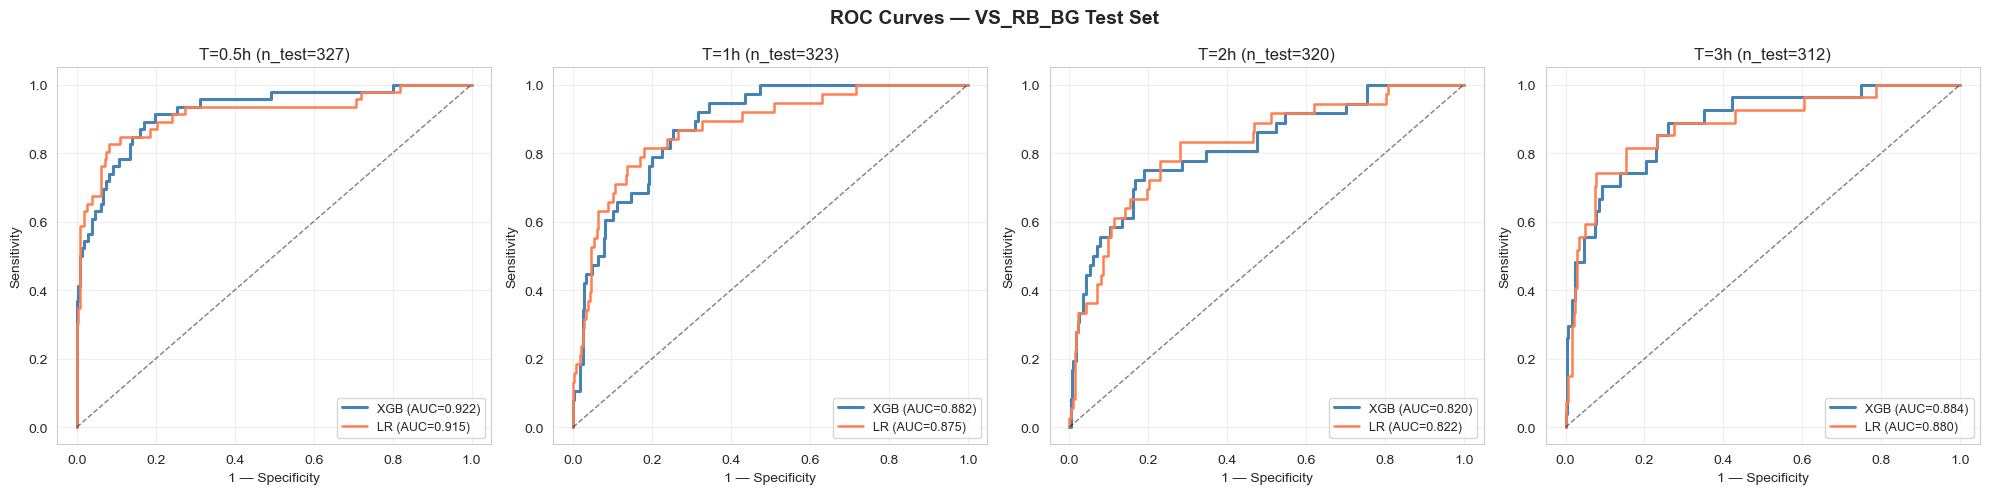

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('ROC Curves — VS_RB_BG Test Set', fontsize=14, fontweight='bold')

colors_xgb = {'0.5': '#e41a1c', '1': '#377eb8', '2': '#4daf4a', '3': '#984ea3'}

for ax, T in zip(axes, TIME_WINDOWS):
    for model_name, color, lw in [('XGB','steelblue',2.2), ('LR','coral',1.8)]:
        te = test_results[T][model_name]
        fpr, tpr, _ = roc_curve(te['_y_true_test'], te['_y_score_test'])
        ax.plot(fpr, tpr, color=color, lw=lw,
                label=f"{model_name} (AUC={te['AUROC']:.3f})")
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('1 — Specificity'); ax.set_ylabel('Sensitivity')
    ax.set_title(f'T={T}h (n_test={test_results[T]["XGB"]["N_test"]})')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'roc_curves_test.png')
plt.show()


## Porównanie z publikacją (Table 3)

In [12]:
PUB_AUROC = {0.5: 0.958, 1: 0.968, 2: 0.952, 3: 0.945}

print("XGBoost VS_RB_BG — CV vs Test vs Publikacja:")
print(f"{'T':>5} | {'CV AUROC':>12} | {'CV CI':>18} | {'Test AUROC':>12} | {'Test CI':>18} | {'Pub AUROC':>10} | {'Δ (test–pub)':>12}")
print('─'*105)
for T in TIME_WINDOWS:
    cv  = cv_results[T]['VS_RB_BG']['XGB']
    te  = test_results[T]['XGB']
    pub = PUB_AUROC.get(T, np.nan)
    delta = te['AUROC'] - pub if not np.isnan(pub) else np.nan
    print(f" T={T}h | {cv['AUROC']:>12.4f} | [{cv['AUROC_CI_lo']:.3f}–{cv['AUROC_CI_hi']:.3f}] | "
          f"{te['AUROC']:>12.4f} | [{te['AUROC_CI_lo']:.3f}–{te['AUROC_CI_hi']:.3f}] | "
          f"{pub:>10.3f} | {delta:>+12.3f}")


XGBoost VS_RB_BG — CV vs Test vs Publikacja:
    T |     CV AUROC |              CV CI |   Test AUROC |            Test CI |  Pub AUROC | Δ (test–pub)
─────────────────────────────────────────────────────────────────────────────────────────────────────────
 T=0.5h |       0.9361 | [0.917–0.951] |       0.9224 | [0.872–0.962] |      0.958 |       -0.036
 T=1h |       0.9219 | [0.898–0.939] |       0.8820 | [0.832–0.924] |      0.968 |       -0.086
 T=2h |       0.8996 | [0.870–0.925] |       0.8196 | [0.743–0.900] |      0.952 |       -0.132
 T=3h |       0.8475 | [0.817–0.885] |       0.8840 | [0.804–0.943] |      0.945 |       -0.061


## SHAP — T=1h, VS_RB_BG

SHAP version: 0.48.0
Computing SHAP values on 323 samples using XGBoost native C++ engine...


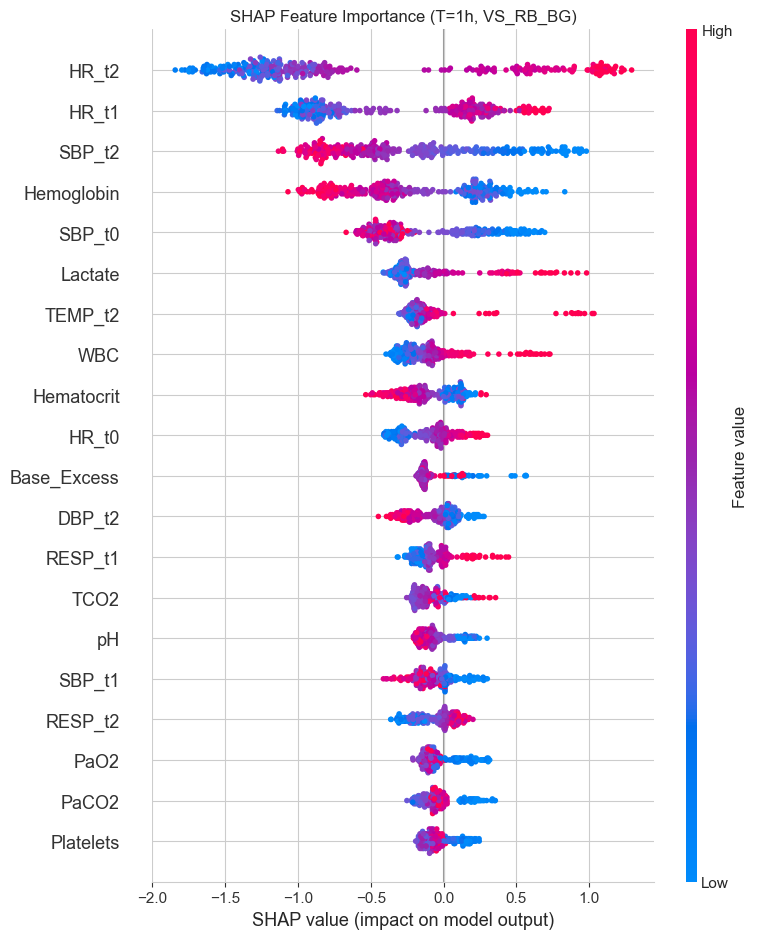

In [13]:
try:
    import shap
    import joblib
    print(f"SHAP version: {shap.__version__}")
    
    # 1. Wybieramy docelowe okno i zestaw cech
    T_shap = 1
    ds_name = 'VS_RB_BG'
    
    # 2. Wczytujemy dane testowe dla tego okna
    te_df = splits[T_shap]['test']
    feat_cols = test_results[T_shap]['feat_cols']
    X_test_df = te_df[feat_cols]
    
    # 3. Wczytujemy zapisany najlepszy model
    best_xgb = joblib.load(config.MODELS_DIR / f'xgb_T{T_shap}h_{ds_name}_final.joblib')
    
    X_shap = X_test_df.sample(n=min(500, len(X_test_df)), random_state=config.RANDOM_SEED)
    print(f"Computing SHAP values on {len(X_shap)} samples using XGBoost native C++ engine...")
    
    # 4. Natywny silnik C++ omijający błąd parsera
    booster = best_xgb.get_booster()
    dmatrix = xgb.DMatrix(X_shap)
    
    shap_contribs = booster.predict(dmatrix, pred_contribs=True)
    shap_values_matrix = shap_contribs[:, :-1]  # odrzucamy kolumnę 'bias'
    
    # 5. Generowanie wykresu
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_matrix, X_shap, show=False)
    plt.title(f'SHAP Feature Importance (T={T_shap}h, {ds_name})')
    plt.tight_layout()
    
    plt.savefig(config.FIGURES_DIR / 'shap_summary_xgb.png', dpi=300, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"SHAP error: {e}")

## Podsumowanie

In [14]:
print("✅ Modeling pipeline complete.")
print()
print("Saved files:")
for f in sorted(config.MODELS_DIR.glob('*.joblib')):
    print(f"  {f.name}")
print()
for f in sorted(config.RESULTS_DIR.glob('*.csv')):
    print(f"  {f.name}")
print()
print("Next step → 04_evaluation.ipynb")


✅ Modeling pipeline complete.

Saved files:
  lr_T0.5h_VS_RB_BG_final.joblib
  lr_T1h_VS_RB_BG_final.joblib
  lr_T2h_VS_RB_BG_final.joblib
  lr_T3h_VS_RB_BG_final.joblib
  xgb_T0.5h_VS_RB_BG_final.joblib
  xgb_T1h_VS_RB_BG_final.joblib
  xgb_T2h_VS_RB_BG_final.joblib
  xgb_T3h_VS_RB_BG_final.joblib

  cm_sens85.csv
  cm_train_youden.csv
  comparison_with_publication.csv
  confusion_matrix_summary.csv
  delong_cv_results.csv
  delong_test_results.csv
  delong_testset_results.csv
  evaluation_full_results.csv
  feature_importance.csv
  modeling_results.csv
  shap_importance_T1h.csv

Next step → 04_evaluation.ipynb
